# Import All Important Libraries

In [1]:
# Import All Important Libraries
from google.colab import files
import pandas as pd
import io

import matplotlib.pyplot as plt
from collections import Counter
import re

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import string

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_auc_score
import numpy as np

from collections import Counter
from imblearn.over_sampling import SMOTE


from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Importing the Dataset

In [2]:
uploaded = files.upload()

for fn in uploaded.keys():
  # reading contents of uploaded file

      df = pd.read_csv(io.StringIO(uploaded[fn].decode('latin-1')), header=None, names=['Label', 'Text'])

# Printing the dataframe
display(df)

Saving all-data.csv to all-data.csv


,Label,Text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4844,negative,Net sales of the Paper segment decreased to EU...


# Performing Data Exploration

Number of Unique Sentiment Labels

In [3]:
# Unique Sentiment Labels
unique_labels = df['Label'].unique()
num_unique_labels = len(unique_labels)

# Printing the unique labels
print(f"Number of unique sentiment labels: {num_unique_labels}")
print(f"Unique sentiment labels: {unique_labels}")

Number of unique sentiment labels: 3
Unique sentiment labels: ['neutral' 'negative' 'positive']


Class Distribution

,count
Label,
neutral,2879
positive,1363
negative,604


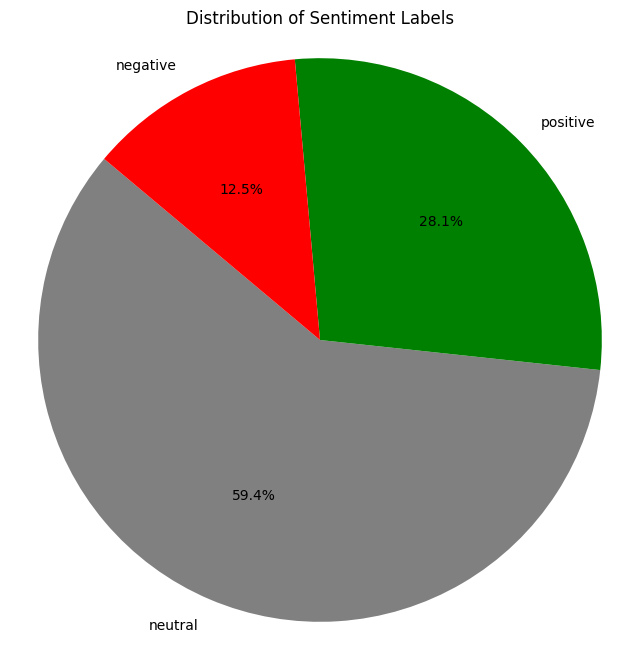

In [4]:
# Show class distribution in a form of a table
display(df['Label'].value_counts())

value_counts = df['Label'].value_counts()

# Define colors for each label
colors = ['gray' if label == 'neutral' else 'green' if label == 'positive' else 'red' for label in value_counts.index]

# Show class distribution in a form of a pie chart with percentages and custom colors
plt.figure(figsize=(8, 8))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Distribution of Sentiment Labels')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Word Frequency

In [5]:
# Sentiment Keyword Examples
# View example texts for each class to better understand what types of language associate with each sentiment
for label in df['Label'].unique():
    print(f"\nExamples for sentiment: '{label}'")
    # Display the first 5 examples for each sentiment class
    for text in df[df['Label'] == label]['Text'].head(2).tolist():
        print(f"- {text}")


Examples for sentiment: 'neutral'
- According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
- Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .

Examples for sentiment: 'negative'
- The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .
- A tinyurl link takes users to a scamming site promising that users can earn thousands of dollars by becoming a Google ( NASDAQ : GOOG ) Cash advertiser .

Examples for sentiment: 'positive'
- With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the p

In [6]:
# Check for missing values in the 'Text' column
missing_text_values = df['Text'].isnull().sum()
print(f"Number of missing text entries: {missing_text_values}")

# Check for missing values in the 'Label' column
missing_label_values = df['Label'].isnull().sum()
print(f"Number of missing Label entries: {missing_label_values}")

# Check for duplicate text entries
duplicate_text_entries = df['Text'].duplicated().sum()
print(f"Number of duplicate text entries: {duplicate_text_entries}")

# Optionally, display the duplicate entries
if duplicate_text_entries > 0:
    print("\nSample of duplicate text entries:")
    display(df[df['Text'].duplicated(keep=False)].sort_values(by='Text').head(20))

Number of missing text entries: 0
Number of missing Label entries: 0
Number of duplicate text entries: 8

Sample of duplicate text entries:


,Label,Text
2395,neutral,Ahlstrom 's share is quoted on the NASDAQ OMX ...
2396,neutral,Ahlstrom 's share is quoted on the NASDAQ OMX ...
3093,neutral,Proha Plc ( Euronext :7327 ) announced today (...
3094,neutral,Proha Plc ( Euronext :7327 ) announced today (...
2566,neutral,SSH Communications Security Corporation is hea...
2567,neutral,SSH Communications Security Corporation is hea...
78,neutral,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...
79,positive,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...
788,positive,The Group 's business is balanced by its broad...
789,neutral,The Group 's business is balanced by its broad...


Text Length Analysis

# Data Preprocessing

Create a copy of the dataset

In [7]:
df_clean = df.copy()
df_clean


,Label,Text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4844,negative,Net sales of the Paper segment decreased to EU...


In [8]:
# Initialize stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):

  # Lowercasing
  text = text.lower()

  # Removing punctuation
  text = text.translate(str.maketrans('', '', string.punctuation))

  # Removing stopwords
  text = ' '.join([word for word in text.split() if word not in stop_words])

  return text

# Apply the cleaning function to the 'Text' column
df_clean['Text'] = df_clean['Text'].apply(clean_text)

# Display one entry from df and df_clean for comparison
print("Original Text (df):")
print(df['Text'].iloc[0])

print("\nCleaned Text (df_clean):")
print(df_clean['Text'].iloc[0])

print()

Original Text (df):
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

Cleaned Text (df_clean):
according gran company plans move production russia although company growing



In [9]:
initial_shape = df_clean.shape
print(f"Shape before removing duplicates: {initial_shape}")

# Calculate the number of duplicates before removal
num_duplicates_found = df_clean.duplicated().sum()
print(f"Number of duplicates found: {num_duplicates_found}")

# Remove duplicates in-place
df_clean.drop_duplicates(inplace=True)

# Calculate the number of duplicates removed
num_duplicates_removed = initial_shape[0] - df_clean.shape[0]
print(f"Number of duplicates removed: {num_duplicates_removed}")

final_shape = df_clean.shape
print(f"Shape after removing duplicates: {final_shape}")

Shape before removing duplicates: (4846, 2)
Number of duplicates found: 15
Number of duplicates removed: 15
Shape after removing duplicates: (4831, 2)


In [10]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Label' column
df_clean['Label_Encoded'] = label_encoder.fit_transform(df_clean['Label'])

# Drop the original 'Label' column
df_clean = df_clean.drop('Label', axis=1)

# Display the dataframe with the new encoded label column
display(df_clean.head())

,Text,Label_Encoded
0,according gran company plans move production r...,1
1,technopolis plans develop stages area less 100...,1
2,international electronic industry company elco...,0
3,new production plant company would increase ca...,2
4,according company updated strategy years 20092...,2


In [11]:
# Identify X,y

X = df_clean['Text']
y = df_clean['Label_Encoded']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (3864,)
Shape of X_test: (967,)
Shape of y_train: (3864,)
Shape of y_test: (967,)


# Model Selection

Support Vector Machine (SVM) Results (Without Optimization):
Training Accuracy: 0.8980331262939959
Testing Accuracy: 0.7394002068252327
Testing AUC (One-vs-Rest): 0.8499022629674524

Confusion Matrix:
 [[ 57  44  15]
 [ 10 508  44]
 [ 16 123 150]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.69      0.49      0.57       116
     neutral       0.75      0.90      0.82       562
    positive       0.72      0.52      0.60       289

    accuracy                           0.74       967
   macro avg       0.72      0.64      0.67       967
weighted avg       0.73      0.74      0.73       967



<Figure size 800x600 with 0 Axes>

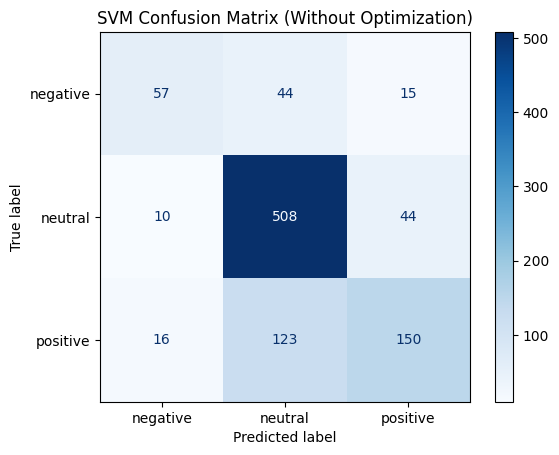

In [13]:
# Vectorize the text data
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Using TF-IDF vectorization
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# # Model Training and Evaluation

## Support Vector Machine (SVM)

# Initialize and train the SVM model
svm_model = SVC(kernel='linear', random_state=42, probability=True) # Using a linear kernel, enable probability for AUC
svm_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
svm_predictions = svm_model.predict(X_test_tfidf)
svm_probabilities = svm_model.predict_proba(X_test_tfidf) # Get probabilities for AUC

# Evaluate the SVM model
print("Support Vector Machine (SVM) Results (Without Optimization):")
print("Training Accuracy:", accuracy_score(y_train, svm_model.predict(X_train_tfidf)))
print("Testing Accuracy:", accuracy_score(y_test, svm_predictions))

# Calculate AUC score (requires probabilities and a multi-class strategy like 'ovo' or 'ovr')
# Let's use 'ovr' (One-vs-Rest) strategy
svm_auc_ovr = roc_auc_score(y_test, svm_probabilities, multi_class='ovr')
print("Testing AUC (One-vs-Rest):", svm_auc_ovr)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_predictions))
print("\nClassification Report:\n", classification_report(y_test, svm_predictions, target_names=label_encoder.classes_))

# Generate Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, svm_predictions)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
# Use label_encoder.classes_ for display_labels
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=label_encoder.classes_)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix (Without Optimization)')
plt.show()

Logistic Regression (LR) Results (Without Optimization):
Training Accuracy: 0.8532608695652174
Testing Accuracy: 0.7300930713547052
Testing AUC (One-vs-Rest): 0.8526550550541058

Confusion Matrix:
 [[ 46  53  17]
 [  6 526  30]
 [ 10 145 134]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.74      0.40      0.52       116
     neutral       0.73      0.94      0.82       562
    positive       0.74      0.46      0.57       289

    accuracy                           0.73       967
   macro avg       0.74      0.60      0.64       967
weighted avg       0.73      0.73      0.71       967



<Figure size 800x600 with 0 Axes>

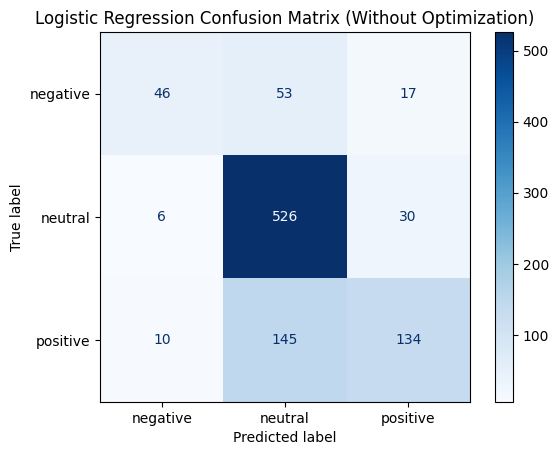

In [14]:
## Logistic Regression (LR)

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence if needed
lr_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
lr_predictions = lr_model.predict(X_test_tfidf)
lr_probabilities = lr_model.predict_proba(X_test_tfidf) # Get probabilities for AUC

# Evaluate the Logistic Regression model
print("Logistic Regression (LR) Results (Without Optimization):")
print("Training Accuracy:", accuracy_score(y_train, lr_model.predict(X_train_tfidf)))
print("Testing Accuracy:", accuracy_score(y_test, lr_predictions))

# Calculate AUC score (requires probabilities and a multi-class strategy like 'ovo' or 'ovr')
# Let's use 'ovr' (One-vs-Rest) strategy
lr_auc_ovr = roc_auc_score(y_test, lr_probabilities, multi_class='ovr')
print("Testing AUC (One-vs-Rest):", lr_auc_ovr)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_predictions))
print("\nClassification Report:\n", classification_report(y_test, lr_predictions, target_names=label_encoder.classes_))

# Generate Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_predictions)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
# Use label_encoder.classes_ for display_labels
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_encoder.classes_)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix (Without Optimization)')
plt.show()

# Optimization

Support Vector Machine (SVM) With Class Weights Results: 
Training Accuracy: 0.9262422360248447
Testing Accuracy: 0.7456049638055843
Testing AUC (One-vs-Rest): 0.8620286632326395

Confusion Matrix:
 [[ 75  25  16]
 [ 24 461  77]
 [ 26  78 185]]

Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.65      0.62       116
     neutral       0.82      0.82      0.82       562
    positive       0.67      0.64      0.65       289

    accuracy                           0.75       967
   macro avg       0.69      0.70      0.70       967
weighted avg       0.75      0.75      0.75       967

Confusion Matrix:


<Figure size 800x600 with 0 Axes>

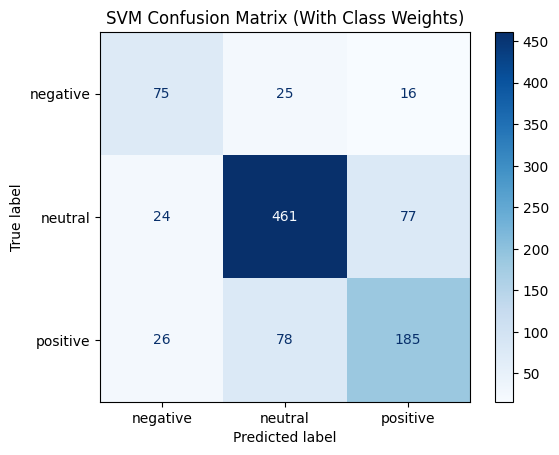

In [15]:
# # Model Training (SVM with TF-IDF and Class Weights)
# Including class_weight='balanced'
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42, probability=True) # enable probability for AUC

# Train the SVM model
svm_model.fit(X_train_tfidf, y_train)

# # Model Evaluation

# Predict on the test data
y_pred = svm_model.predict(X_test_tfidf)
svm_probabilities = svm_model.predict_proba(X_test_tfidf) # Get probabilities for AUC

# Generate Classification Report
print("Support Vector Machine (SVM) With Class Weights Results: ")
print("Training Accuracy:", accuracy_score(y_train, svm_model.predict(X_train_tfidf)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

# Calculate AUC score (requires probabilities and a multi-class strategy like 'ovo' or 'ovr')
# Let's use 'ovr' (One-vs-Rest) strategy
svm_auc_ovr = roc_auc_score(y_test, svm_probabilities, multi_class='ovr')
print("Testing AUC (One-vs-Rest):", svm_auc_ovr)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
# target_names can be obtained from the unique original labels, ordered by their encoded value
target_names = label_encoder.inverse_transform(np.unique(y_train))
print(classification_report(y_test, y_pred, target_names=target_names))

# Generate Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix (With Class Weights)')
plt.show()

Logistic Regression With Class Weights Results: 
Training Accuracy: 0.9195134575569358
Testing Accuracy:  0.7259565667011375
Testing AUC (One-vs-Rest): 0.85655221798632

Confusion Matrix:
 [[ 75  27  14]
 [ 32 455  75]
 [ 25  92 172]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.65      0.60       116
     neutral       0.79      0.81      0.80       562
    positive       0.66      0.60      0.63       289

    accuracy                           0.73       967
   macro avg       0.67      0.68      0.68       967
weighted avg       0.73      0.73      0.73       967

Logistic Regression Confusion Matrix:


<Figure size 800x600 with 0 Axes>

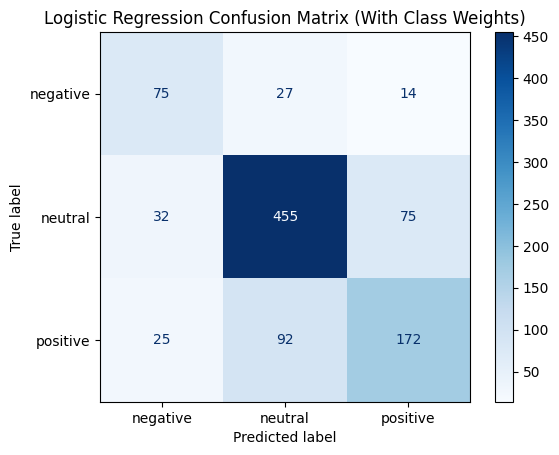

In [16]:
# Initialize Logistic Regression Classifier
# Including class_weight='balanced'
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000) # Increased max_iter for convergence

# Train the Logistic Regression model
lr_model.fit(X_train_tfidf, y_train)

# Predict on the test data
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_probabilities = lr_model.predict_proba(X_test_tfidf) # Get probabilities for AUC

# Generate Classification Report
print("Logistic Regression With Class Weights Results: ")
print("Training Accuracy:", accuracy_score(y_train, lr_model.predict(X_train_tfidf)))
print("Testing Accuracy: ", accuracy_score(y_test, y_pred_lr))

# Calculate AUC score (requires probabilities and a multi-class strategy like 'ovo' or 'ovr')
# Let's use 'ovr' (One-vs-Rest) strategy
lr_auc_ovr = roc_auc_score(y_test, lr_probabilities, multi_class='ovr')
print("Testing AUC (One-vs-Rest):", lr_auc_ovr)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:")
# target_names can be obtained from the unique original labels, ordered by their encoded value
target_names_lr = label_encoder.inverse_transform(np.unique(y_train))
print(classification_report(y_test, y_pred_lr, target_names=target_names_lr))

# Generate Confusion Matrix
print("Logistic Regression Confusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=target_names_lr)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix (With Class Weights)')
plt.show()

Original training class distribution:
Counter({1: 2302, 2: 1074, 0: 488})

SMOTE-resampled training class distribution:
Counter({1: 2302, 2: 2302, 0: 2302})

Support Vector Machine (SVM) (With SMOTE) Results:
Training Accuracy: 0.9661164205039097
Testing Accuracy: 0.7456049638055843
Testing AUC (One-vs-Rest): 0.8564048358882194

Confusion Matrix:
 [[ 67  30  19]
 [ 23 467  72]
 [ 20  82 187]]

SVM Classification Report (with SMOTE):
              precision    recall  f1-score   support

    negative       0.61      0.58      0.59       116
     neutral       0.81      0.83      0.82       562
    positive       0.67      0.65      0.66       289

    accuracy                           0.75       967
   macro avg       0.70      0.69      0.69       967
weighted avg       0.74      0.75      0.74       967

SVM Confusion Matrix (with SMOTE):


<Figure size 800x600 with 0 Axes>

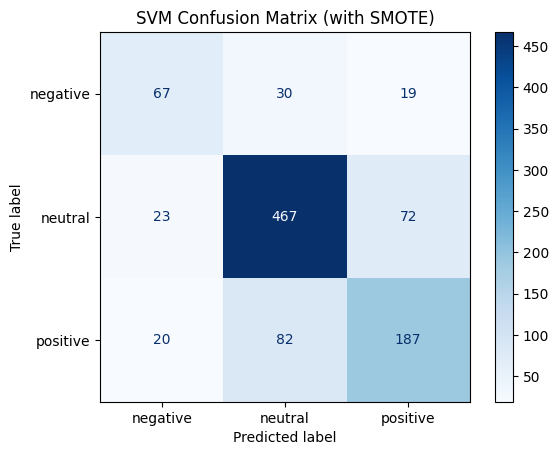

In [17]:
# Initialize SMOTE
smote = SMOTE(sampling_strategy='not majority', random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print("Original training class distribution:")
print(Counter(y_train))

print("\nSMOTE-resampled training class distribution:")
print(Counter(y_train_smote))

# Train the SVM model with SMOTE-resampled data
svm_model_smote = SVC(kernel='linear', random_state=42, probability=True) # Removed class_weight, enable probability for AUC
svm_model_smote.fit(X_train_smote, y_train_smote)

# Predict on the test data (which was NOT oversampled)
y_pred_svm_smote = svm_model_smote.predict(X_test_tfidf)
svm_probabilities_smote = svm_model_smote.predict_proba(X_test_tfidf) # Get probabilities for AUC

# Evaluate SVM model with SMOTE-resampled data
print("\nSupport Vector Machine (SVM) (With SMOTE) Results:")
print("Training Accuracy:", accuracy_score(y_train_smote, svm_model_smote.predict(X_train_smote)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_svm_smote))

# Calculate AUC score (requires probabilities and a multi-class strategy like 'ovo' or 'ovr')
# Let's use 'ovr' (One-vs-Rest) strategy
svm_auc_ovr_smote = roc_auc_score(y_test, svm_probabilities_smote, multi_class='ovr')
print("Testing AUC (One-vs-Rest):", svm_auc_ovr_smote)


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_smote))
print("\nSVM Classification Report (with SMOTE):")
target_names_svm = label_encoder.inverse_transform(np.unique(y_train))
print(classification_report(y_test, y_pred_svm_smote, target_names=target_names_svm))

# Generate Confusion Matrix for SVM (with SMOTE)
print("SVM Confusion Matrix (with SMOTE):")
cm_svm_smote = confusion_matrix(y_test, y_pred_svm_smote)
plt.figure(figsize=(8, 6))
disp_svm_smote = ConfusionMatrixDisplay(confusion_matrix=cm_svm_smote, display_labels=target_names_svm)
disp_svm_smote.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix (with SMOTE)')
plt.show()


Logistic Regression (With SMOTE) Results: 
Training Accuracy: 0.9520706631914277
Testing Accuracy:  0.7311271975180972
Testing AUC (One-vs-Rest): 0.8563999063322937

Confusion Matrix:
 [[ 69  34  13]
 [ 26 467  69]
 [ 25  93 171]]

Logistic Regression Classification Report (with SMOTE):
              precision    recall  f1-score   support

    negative       0.57      0.59      0.58       116
     neutral       0.79      0.83      0.81       562
    positive       0.68      0.59      0.63       289

    accuracy                           0.73       967
   macro avg       0.68      0.67      0.67       967
weighted avg       0.73      0.73      0.73       967

Logistic Regression Confusion Matrix (with SMOTE):


<Figure size 800x600 with 0 Axes>

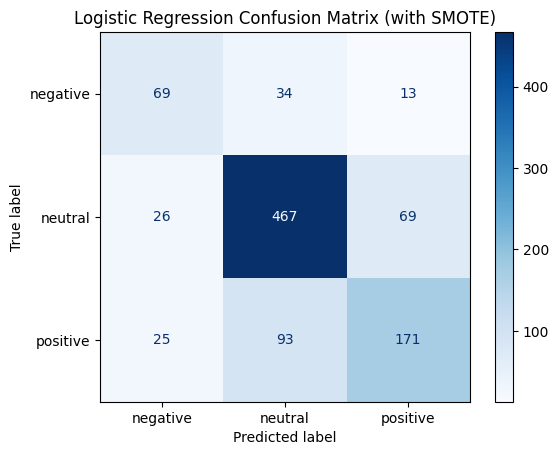

In [18]:
# Train the Logistic Regression model with SMOTE-resampled data
lr_model_smote = LogisticRegression(random_state=42, max_iter=1000) # Removed class_weight
lr_model_smote.fit(X_train_smote, y_train_smote)

# Predict on the test data (which was NOT oversampled)
y_pred_lr_smote = lr_model_smote.predict(X_test_tfidf)
lr_probabilities_smote = lr_model_smote.predict_proba(X_test_tfidf) # Get probabilities for AUC

# Evaluate Logistic Regression model with SMOTE-resampled data
print("\nLogistic Regression (With SMOTE) Results: ")
print("Training Accuracy:", accuracy_score(y_train_smote, lr_model_smote.predict(X_train_smote)))
print("Testing Accuracy: ", accuracy_score(y_test, y_pred_lr_smote))

# Calculate AUC score (requires probabilities and a multi-class strategy like 'ovo' or 'ovr')
# Let's use 'ovr' (One-vs-Rest) strategy
lr_auc_ovr_smote = roc_auc_score(y_test, lr_probabilities_smote, multi_class='ovr')
print("Testing AUC (One-vs-Rest):", lr_auc_ovr_smote)


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_smote))
print("\nLogistic Regression Classification Report (with SMOTE):")
target_names_lr = label_encoder.inverse_transform(np.unique(y_train))
print(classification_report(y_test, y_pred_lr_smote, target_names=target_names_lr))

# Generate Confusion Matrix for Logistic Regression (with SMOTE)
print("Logistic Regression Confusion Matrix (with SMOTE):")
cm_lr_smote = confusion_matrix(y_test, y_pred_lr_smote)
plt.figure(figsize=(8, 6))
disp_lr_smote = ConfusionMatrixDisplay(confusion_matrix=cm_lr_smote, display_labels=target_names_lr)
disp_lr_smote.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix (with SMOTE)')
plt.show()